In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torch.autograd.variable import Variable
from torchvision import transforms, datasets

import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def real_data_target(size):
    data = Variable(torch.ones(size, 1)).to(device)
    return data

def fake_data_target(size):
    data = Variable(torch.zeros(size, 1)).to(device)
    return data

In [ ]:
def imgs_to_vec(imgs, img_size=28):
    return imgs.view(imgs.size(0), img_size * img_size)

In [ ]:
def vec_to_imgs(vec):
    return vec.view(vec.size(0), 1, 28, 28)

In [ ]:
def noise(size, batch_size=128):
    n = Variable(torch.randn(size, batch_size))
    return n

In [ ]:
log_data = []

def log(e, E, b, B, de, ge):
    row = {
        'epoch': e, 'epochs': E,
        'batch': b, 'batches': B,
        'derror': de, 'gerror': ge,
    }

def display_logs(e, E, b, B, de, ge, dr, df, batch_size=128):
    print(f"Epoch {e+1}/{E} ({(e/E)*100:.1f}%):"
          f" [{b*batch_size}/{B*batch_size}] ({(b/B)*100:.1f}%)"
          f" D Error: {de:.4f} G Error: {ge:.4f}")

In [ ]:
def display_images(imgs):
    fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(8,8))
    count = 0
    for y in range(4):
        for x in range(4):
            img = imgs[count].view(28, 28)
            axs[y][x].imshow(img, cmap="gray")
            count += 1
    plt.show()


In [ ]:
def mnist_data():
    compose = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])])
    out_dir = '/mnist/'
    return datasets.MNIST(root=out_dir, train=True,
                          transform=compose, download=True)

In [ ]:
data = mnist_data()

data_loader = DataLoader(data, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 50.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.66MB/s]


In [ ]:
class DiscriminatorNet(nn.Module):
    def __init__(self, n_out=1, img_size=28):
        super(DiscriminatorNet, self).__init__()

        self.hidden0 = nn.Sequential(
            nn.Linear(img_size * img_size, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.hidden1 = nn.Sequential(
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.out = nn.Sequential(
            nn.Linear(256, n_out),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.out(x)
        return x

In [ ]:
class GeneratorNet(nn.Module):
    def __init__(self, batch_size=128, img_size=28):
        super(GeneratorNet, self).__init__()

        self.hidden0 = nn.Sequential(
            nn.Linear(batch_size, 256),
            nn.LeakyReLU(0.2),
        )
        self.hidden1 = nn.Sequential(
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
        )
        self.out = nn.Sequential(
            nn.Linear(1024, img_size * img_size),
            nn.Tanh(),
        )

    def forward(self, x):
        x = self.hidden0(x)
        x = self.hidden1(x)
        x = self.hidden2(x)
        x = self.out(x)
        return x

In [ ]:
discriminator = DiscriminatorNet().to(device)
generator = GeneratorNet().to(device)

In [ ]:
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)

In [ ]:
loss = nn.BCELoss()

In [ ]:
EPOCHS = 100

In [ ]:
def train_discriminator(dmodel, optimizer, loss_func, real_data, fake_data):
    optimizer.zero_grad()
    pred_real = dmodel(real_data)
    error_real = loss_func(pred_real, real_data_target(real_data.size(0)))
    error_real.backward()
    pred_fake = dmodel(fake_data)
    error_fake = loss_func(pred_fake, fake_data_target(real_data.size(0)))
    error_fake.backward()
    optimizer.step()
    return error_real + error_fake, pred_real, pred_fake

In [ ]:
def train_generator(dmodel, optimizer, loss_func, fake_data):
    optimizer.zero_grad()
    pred = dmodel(fake_data)
    error = loss_func(pred, real_data_target(pred.size(0)))
    error.backward()
    optimizer.step()
    return error

In [ ]:
NUM_BATCHES = len(data_loader)
DISPLAY_EVERY = 1000

In [ ]:
num_samples = 16
test_noise = noise(num_samples)


tensor([[-0.8655, -0.4923,  0.8225,  ..., -2.9428,  2.2682, -1.1106],
        [-1.0799, -0.2750,  0.9459,  ...,  0.6606, -2.2739, -1.5073],
        [-0.9961,  0.0406,  2.3472,  ..., -1.6941, -0.1986,  0.7196],
        ...,
        [-1.9908, -0.1455,  0.0932,  ...,  1.8366, -0.1335,  1.6155],
        [ 0.0284, -1.8812,  0.3771,  ..., -0.9799, -0.6291, -0.2898],
        [ 0.4637, -0.1376, -0.6034,  ...,  0.0100, -0.6046,  0.1166]])

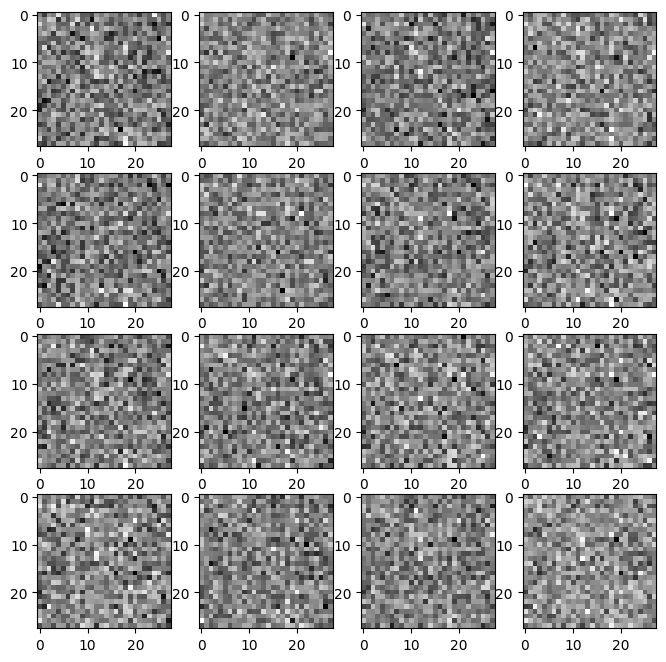

Epoch 1/200 (0.0%): [0/60032] (0.0%) D Error: 1.3751 G Error: 0.7141


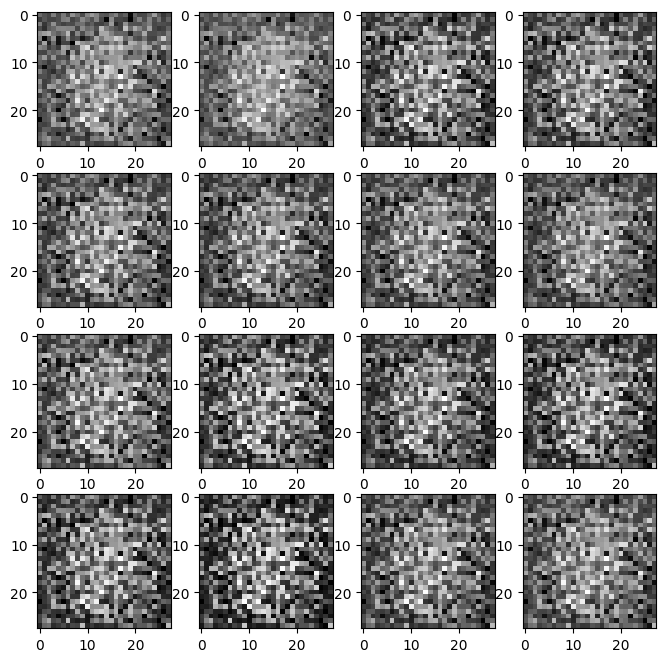

Epoch 2/200 (0.5%): [0/60032] (0.0%) D Error: 1.3022 G Error: 1.2334


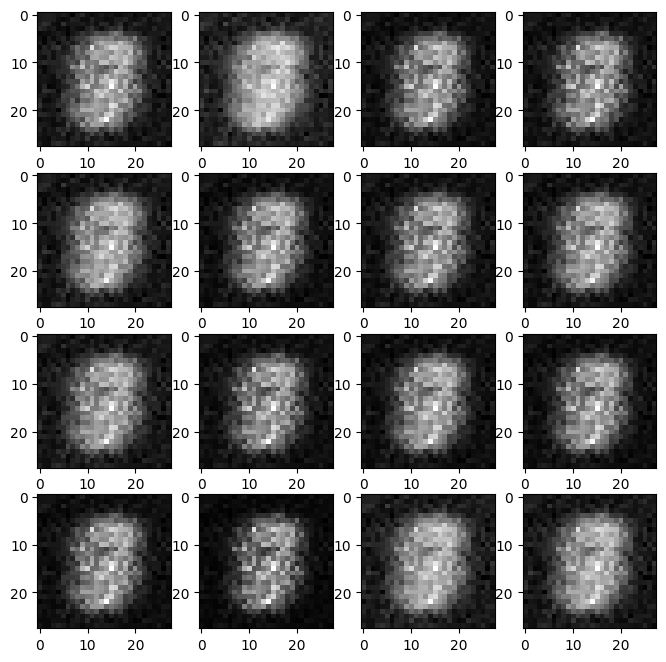

Epoch 3/200 (1.0%): [0/60032] (0.0%) D Error: 1.4063 G Error: 0.6537


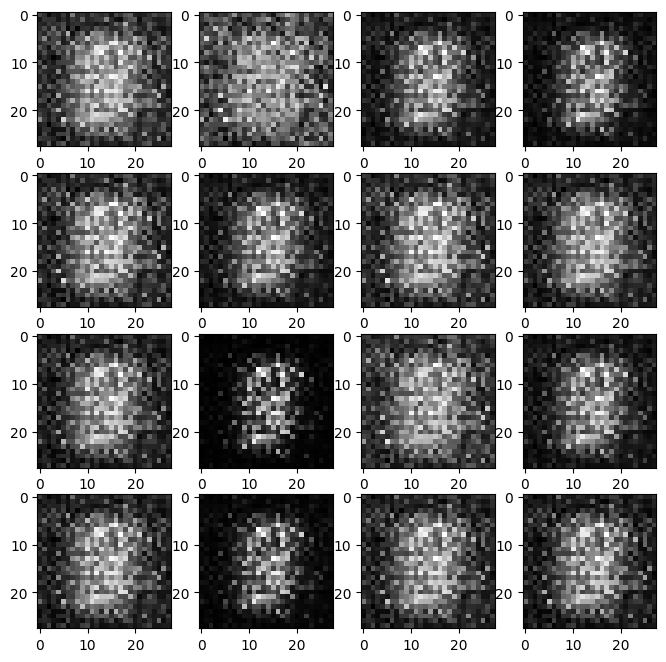

Epoch 4/200 (1.5%): [0/60032] (0.0%) D Error: 0.2161 G Error: 4.4381


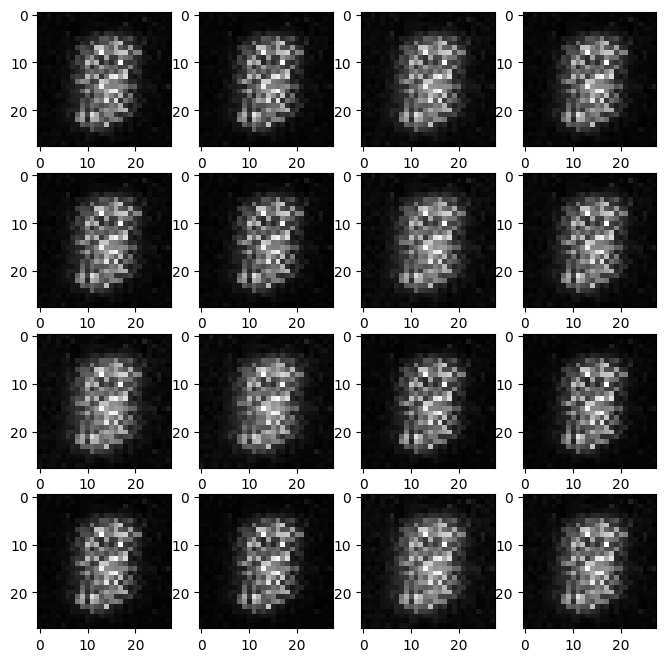

Epoch 5/200 (2.0%): [0/60032] (0.0%) D Error: 0.8403 G Error: 1.5866


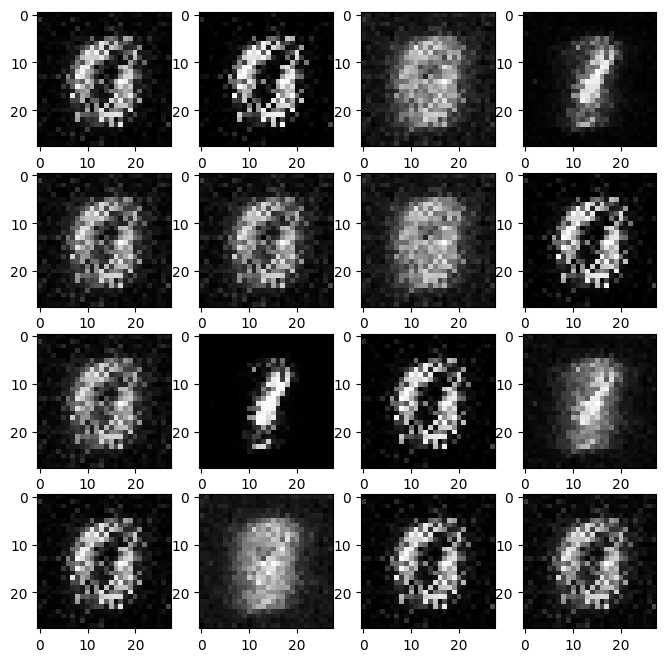

Epoch 6/200 (2.5%): [0/60032] (0.0%) D Error: 0.6067 G Error: 2.5134


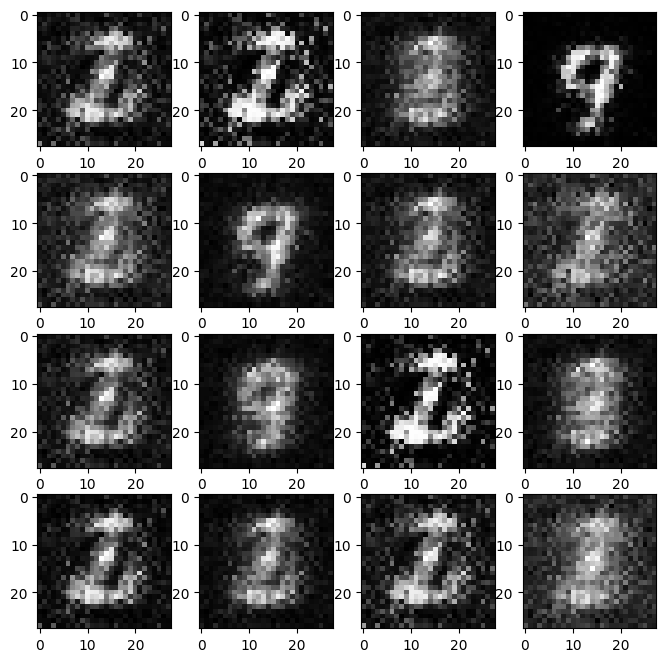

Epoch 7/200 (3.0%): [0/60032] (0.0%) D Error: 0.6460 G Error: 3.2908


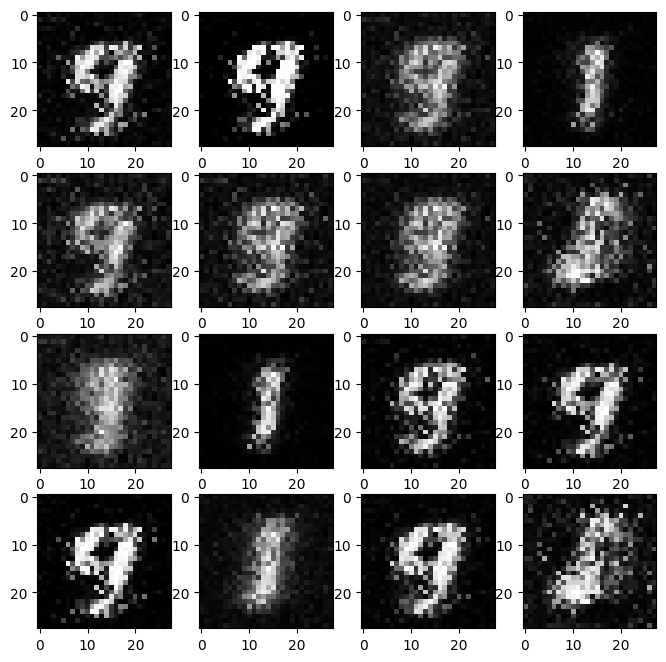

Epoch 8/200 (3.5%): [0/60032] (0.0%) D Error: 0.2883 G Error: 2.9773


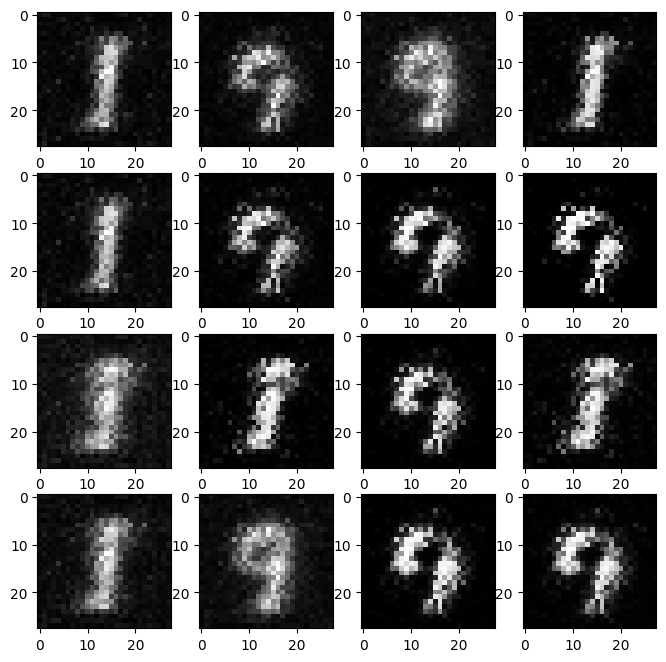

Epoch 9/200 (4.0%): [0/60032] (0.0%) D Error: 0.2063 G Error: 3.0056


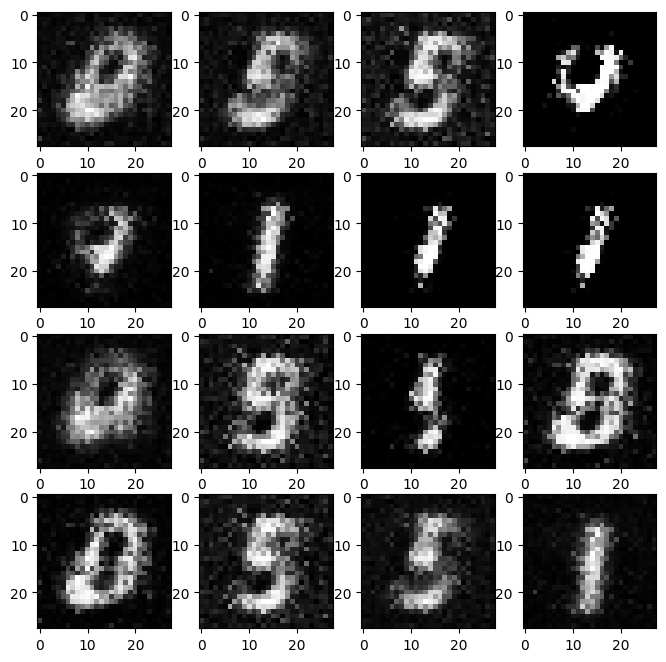

Epoch 10/200 (4.5%): [0/60032] (0.0%) D Error: 0.3941 G Error: 2.3046


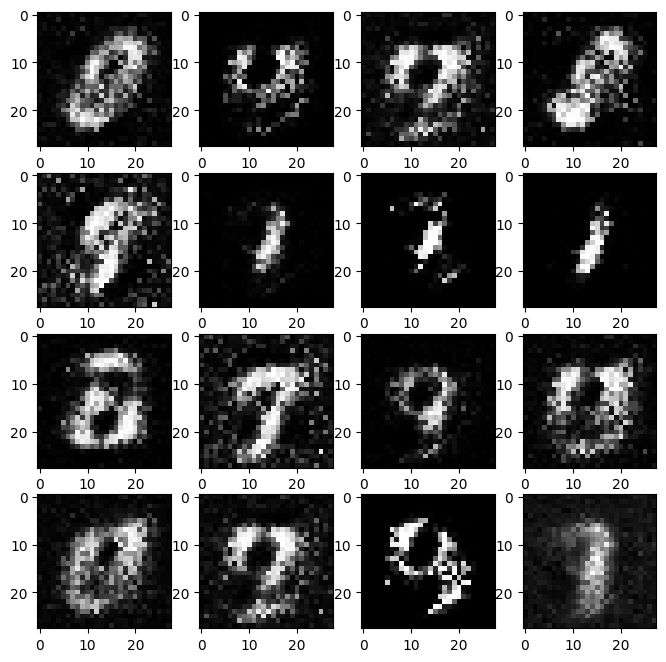

Epoch 11/200 (5.0%): [0/60032] (0.0%) D Error: 0.4068 G Error: 2.6934


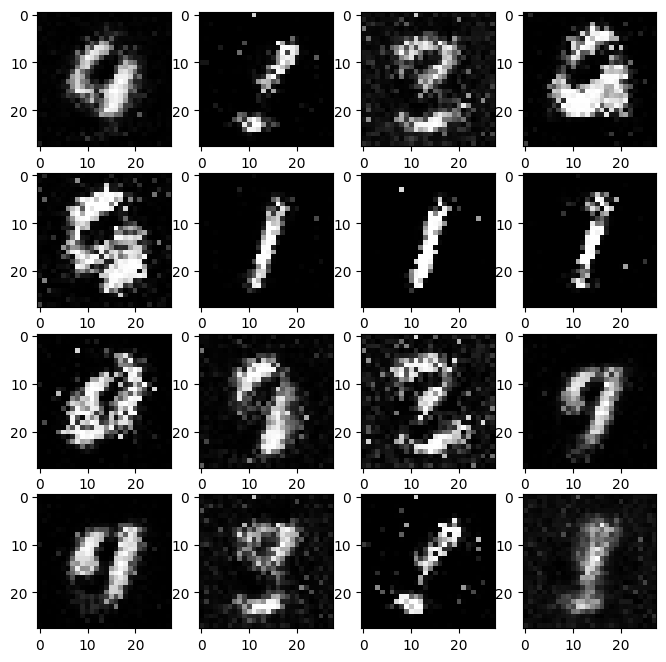

Epoch 12/200 (5.5%): [0/60032] (0.0%) D Error: 0.3716 G Error: 2.5734


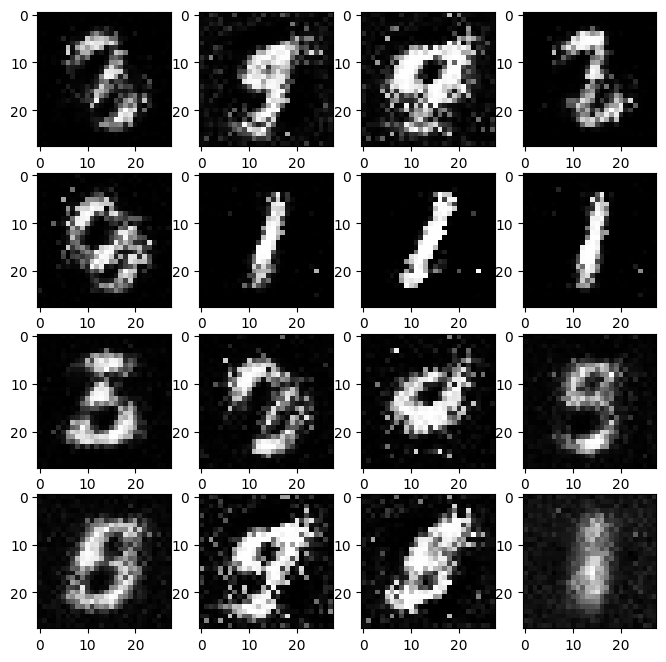

Epoch 13/200 (6.0%): [0/60032] (0.0%) D Error: 0.5459 G Error: 2.9810


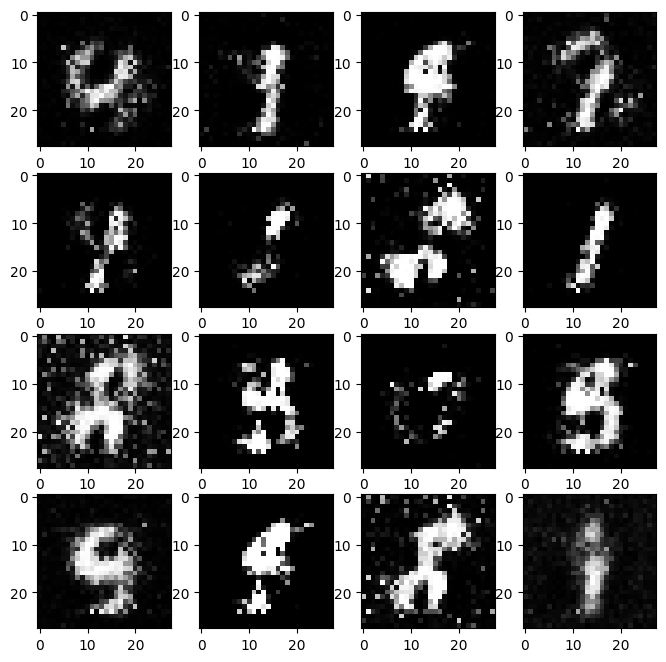

Epoch 14/200 (6.5%): [0/60032] (0.0%) D Error: 0.6474 G Error: 2.6207


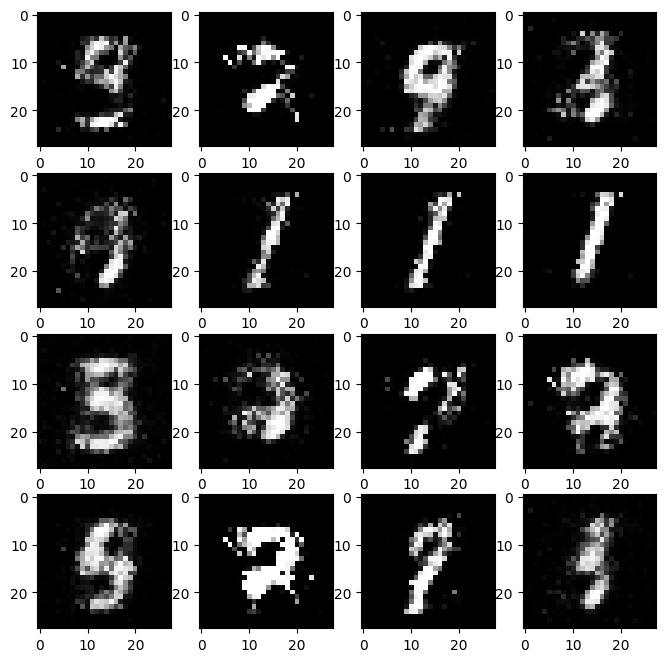

Epoch 15/200 (7.0%): [0/60032] (0.0%) D Error: 0.9987 G Error: 1.8289


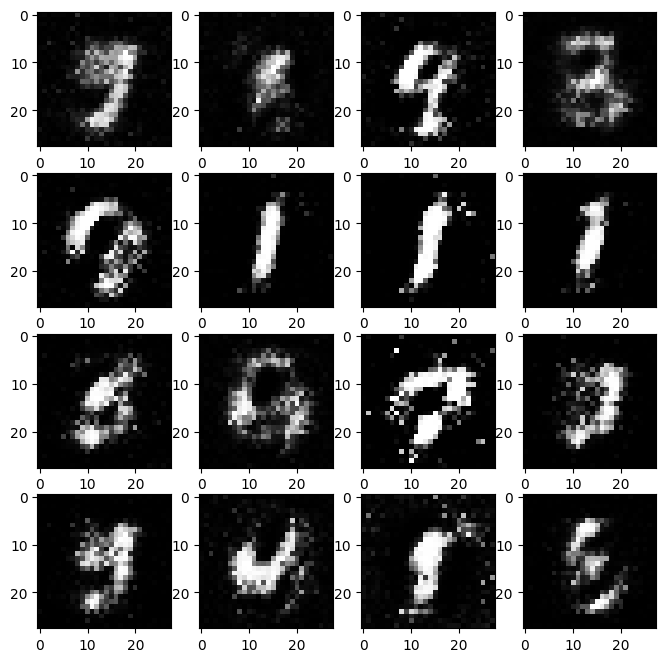

Epoch 16/200 (7.5%): [0/60032] (0.0%) D Error: 0.5350 G Error: 2.2369


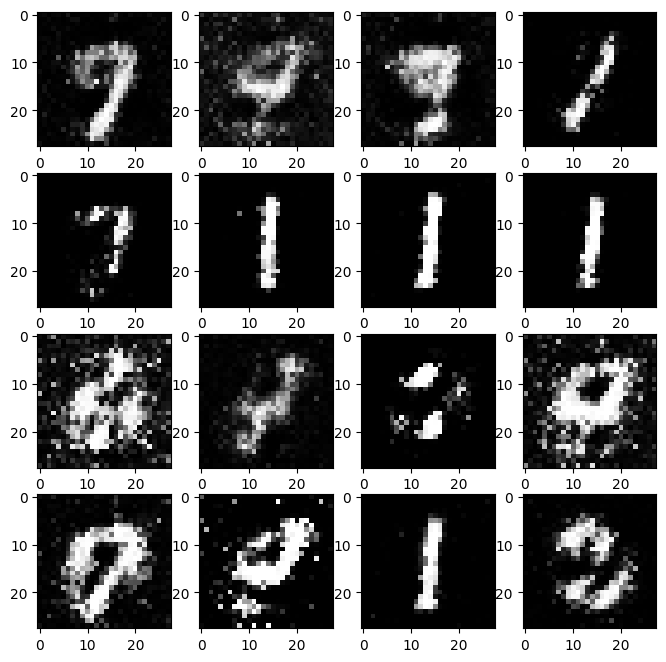

Epoch 17/200 (8.0%): [0/60032] (0.0%) D Error: 0.6625 G Error: 2.0396


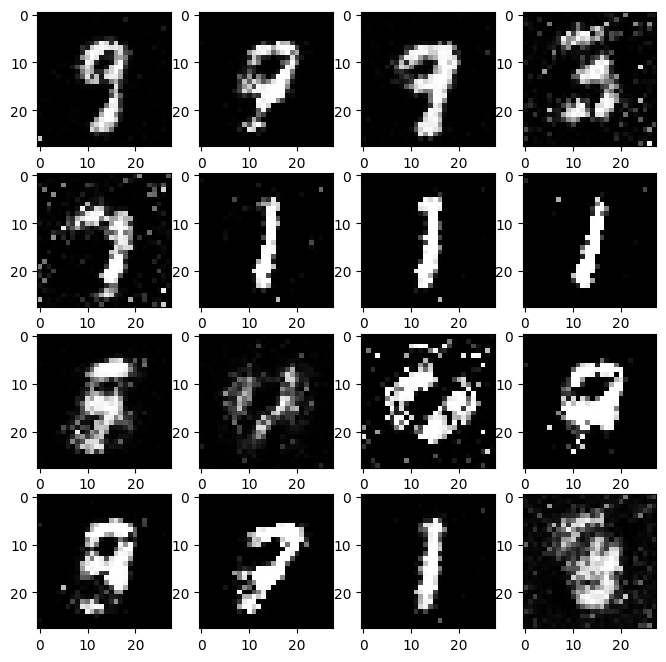

Epoch 18/200 (8.5%): [0/60032] (0.0%) D Error: 0.7285 G Error: 2.2358


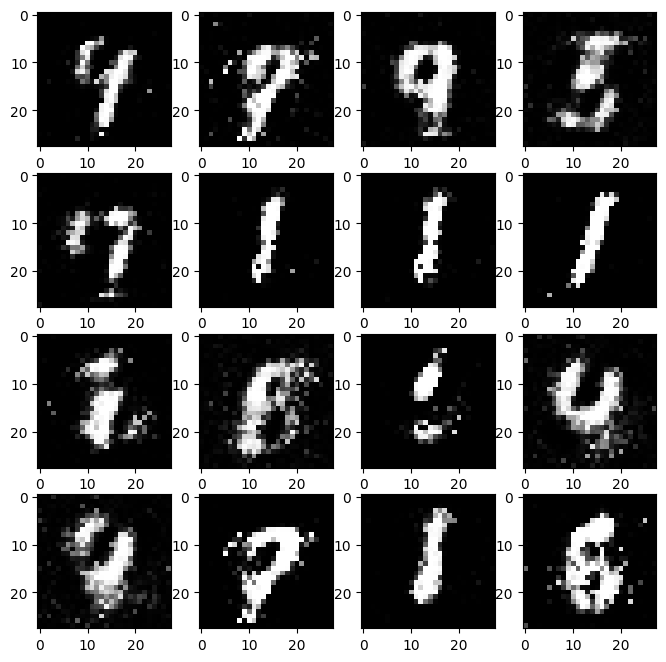

Epoch 19/200 (9.0%): [0/60032] (0.0%) D Error: 0.5414 G Error: 2.7384


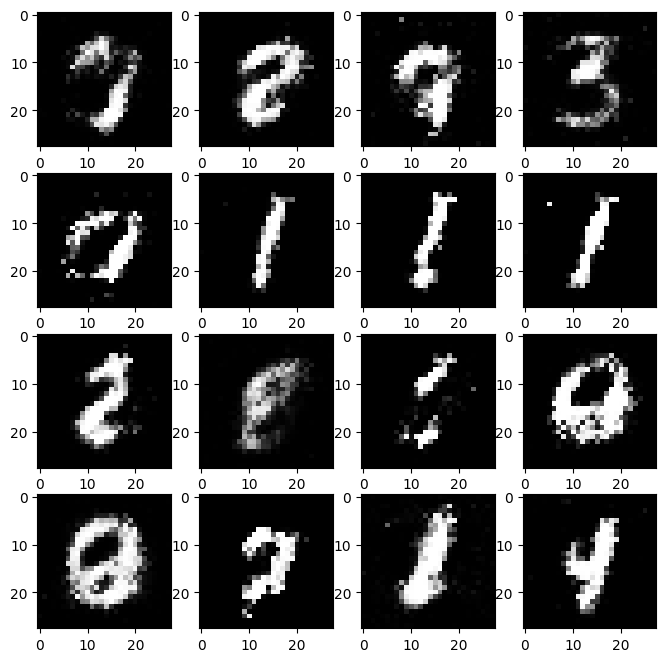

Epoch 20/200 (9.5%): [0/60032] (0.0%) D Error: 0.9937 G Error: 1.3935


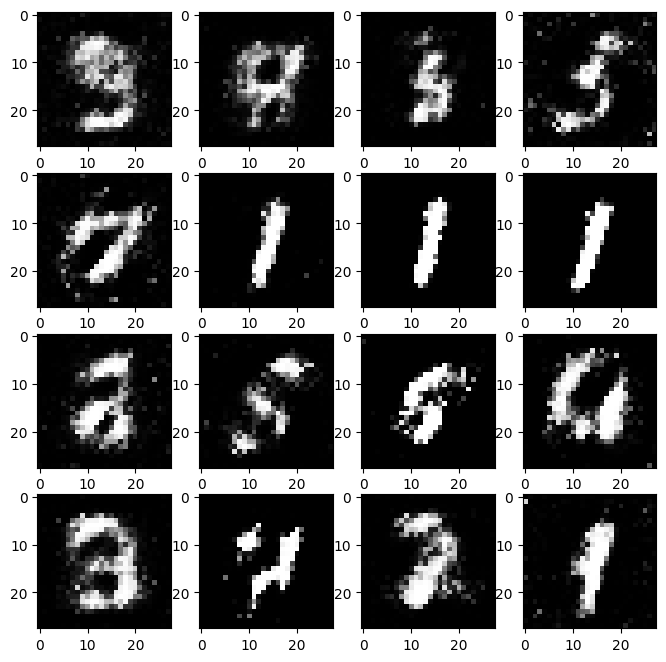

Epoch 21/200 (10.0%): [0/60032] (0.0%) D Error: 1.0958 G Error: 1.8518


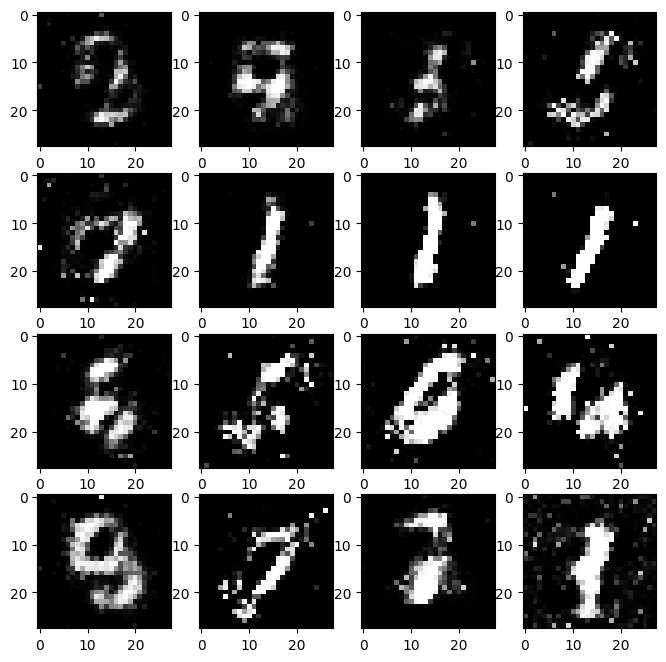

Epoch 22/200 (10.5%): [0/60032] (0.0%) D Error: 0.4221 G Error: 2.6381


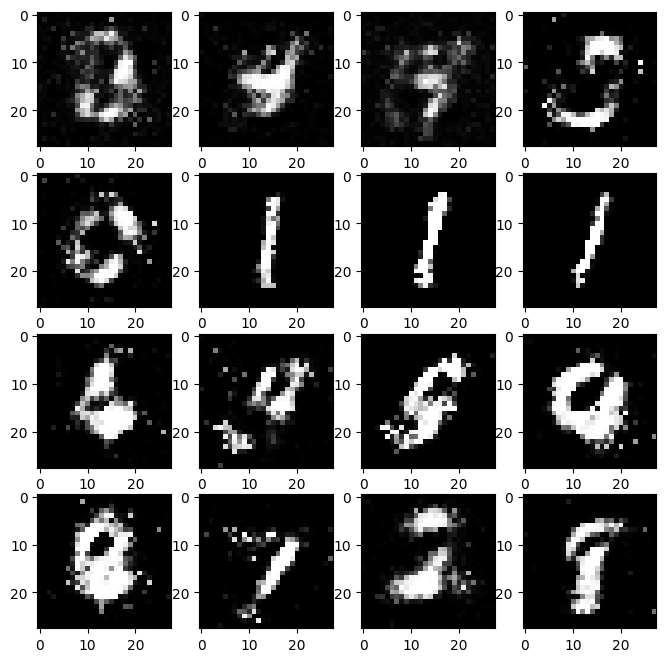

Epoch 23/200 (11.0%): [0/60032] (0.0%) D Error: 0.8345 G Error: 1.8424


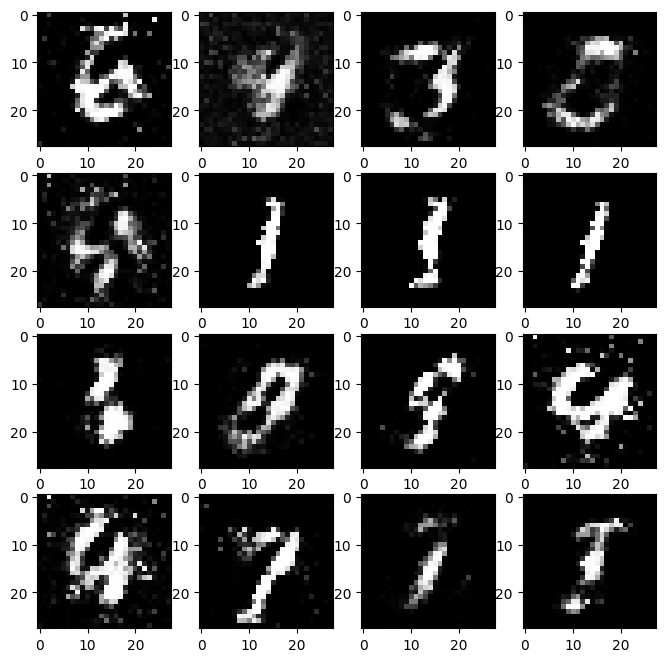

Epoch 24/200 (11.5%): [0/60032] (0.0%) D Error: 0.7344 G Error: 2.4501


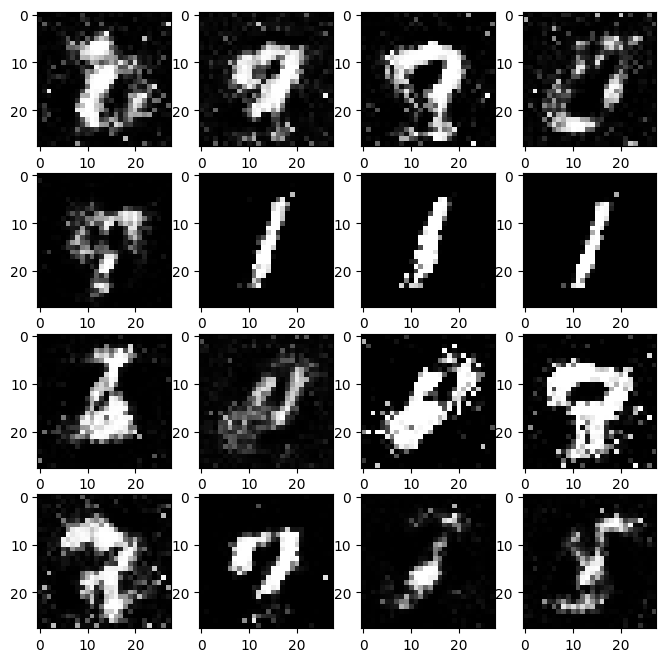

Epoch 25/200 (12.0%): [0/60032] (0.0%) D Error: 0.8430 G Error: 1.6645


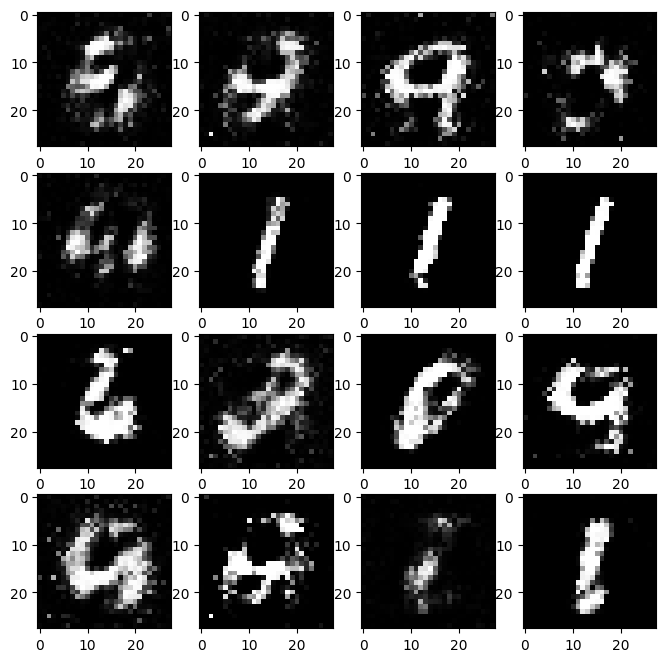

Epoch 26/200 (12.5%): [0/60032] (0.0%) D Error: 0.8999 G Error: 2.3048


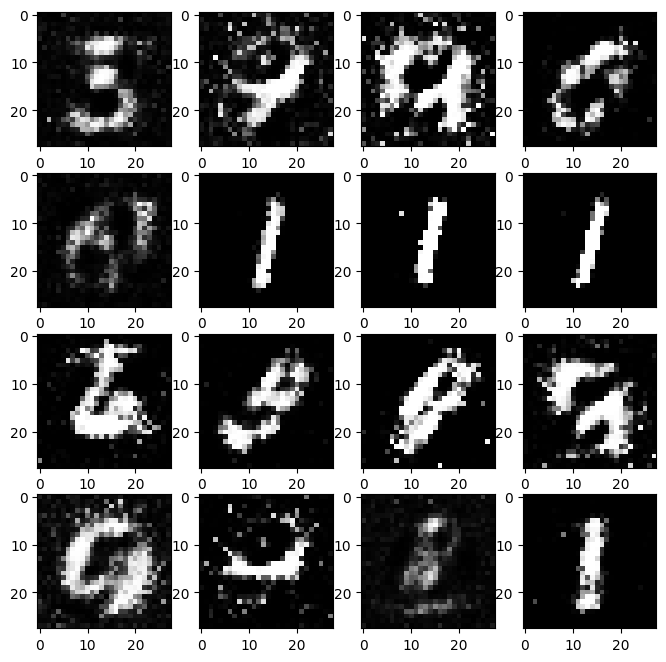

Epoch 27/200 (13.0%): [0/60032] (0.0%) D Error: 0.9524 G Error: 1.2385


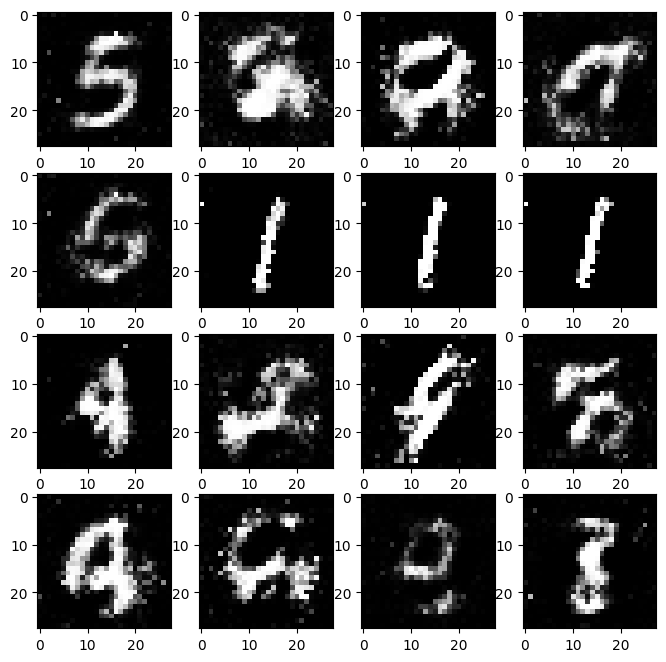

Epoch 28/200 (13.5%): [0/60032] (0.0%) D Error: 1.0683 G Error: 1.2959


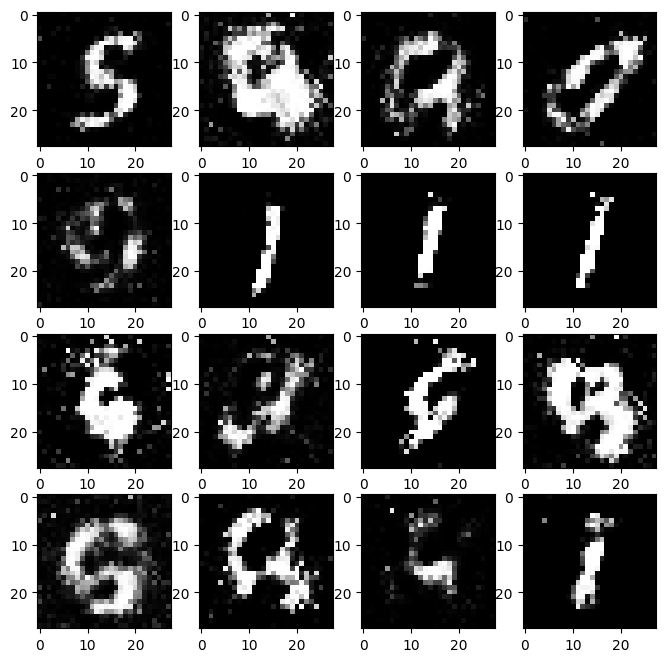

Epoch 29/200 (14.0%): [0/60032] (0.0%) D Error: 0.9643 G Error: 1.3490


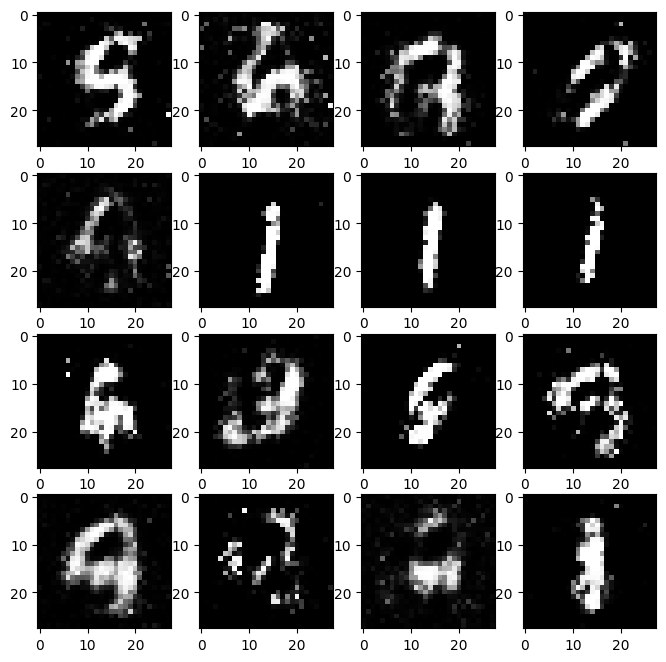

Epoch 30/200 (14.5%): [0/60032] (0.0%) D Error: 1.0214 G Error: 1.5537


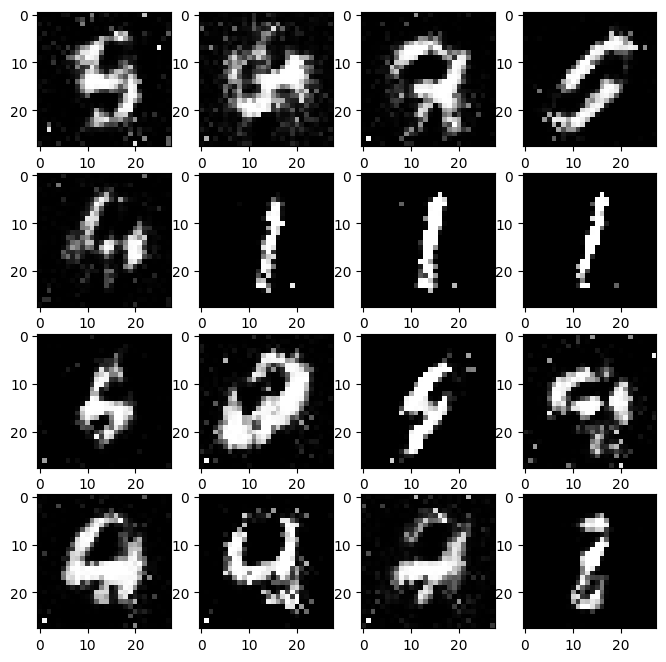

Epoch 31/200 (15.0%): [0/60032] (0.0%) D Error: 0.8772 G Error: 1.6578


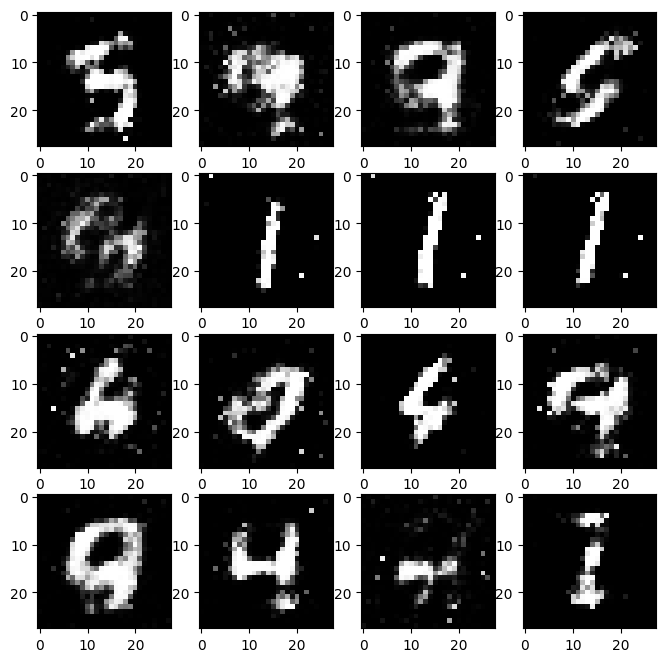

Epoch 32/200 (15.5%): [0/60032] (0.0%) D Error: 0.7421 G Error: 2.4563


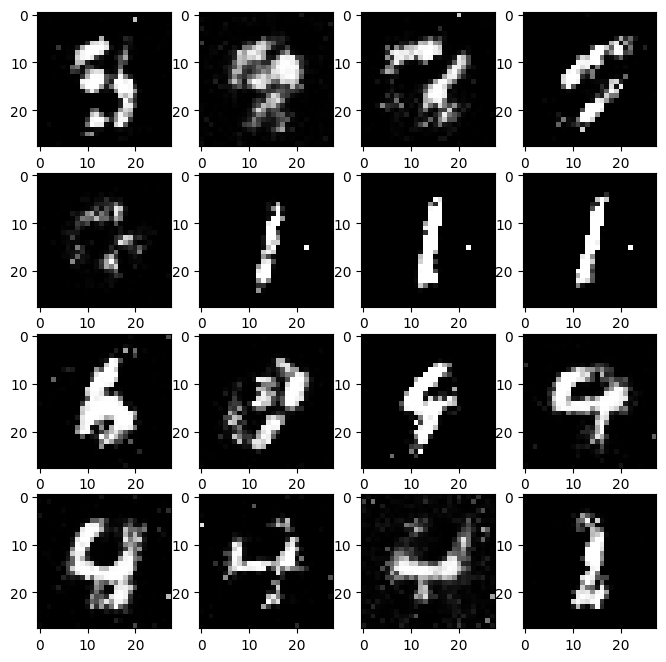

Epoch 33/200 (16.0%): [0/60032] (0.0%) D Error: 1.0691 G Error: 1.3190


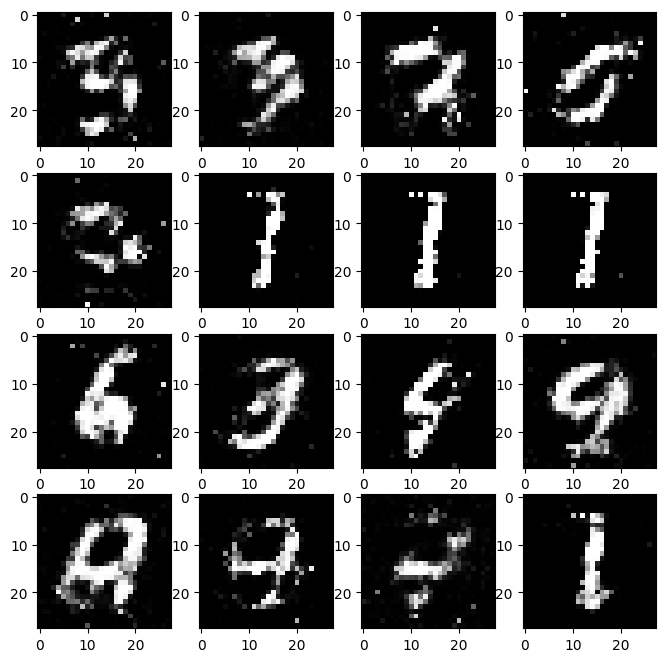

Epoch 34/200 (16.5%): [0/60032] (0.0%) D Error: 0.9007 G Error: 1.4925


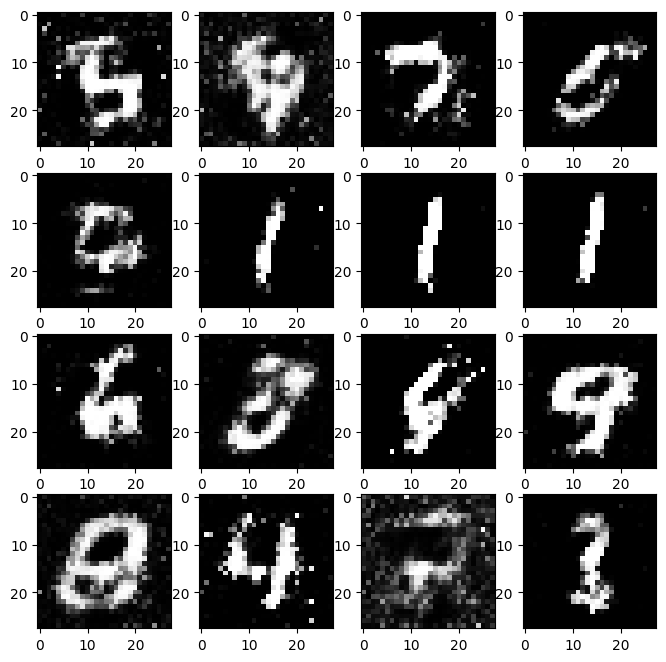

Epoch 35/200 (17.0%): [0/60032] (0.0%) D Error: 0.7151 G Error: 1.9058


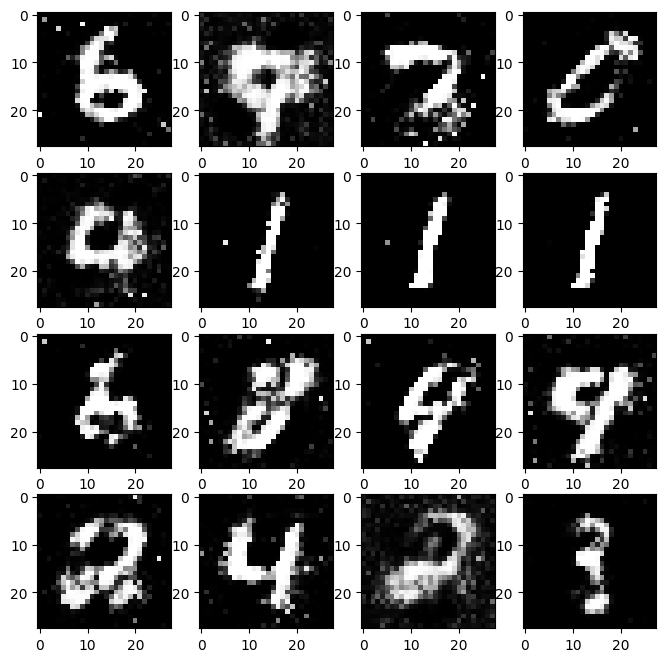

Epoch 36/200 (17.5%): [0/60032] (0.0%) D Error: 0.8534 G Error: 1.4839


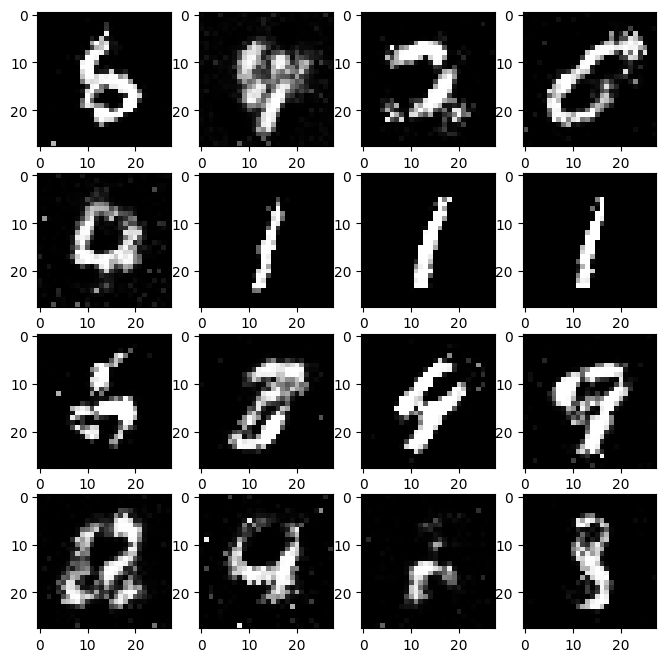

Epoch 37/200 (18.0%): [0/60032] (0.0%) D Error: 1.0440 G Error: 1.4145


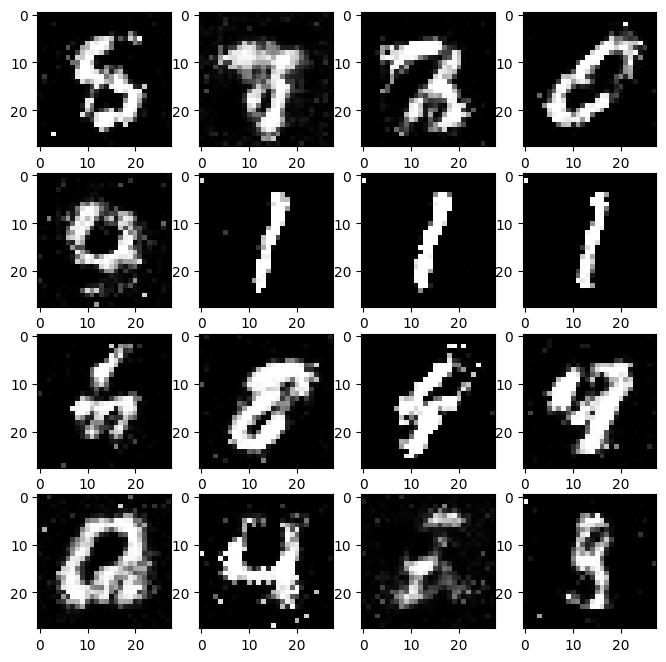

Epoch 38/200 (18.5%): [0/60032] (0.0%) D Error: 0.9544 G Error: 1.6450


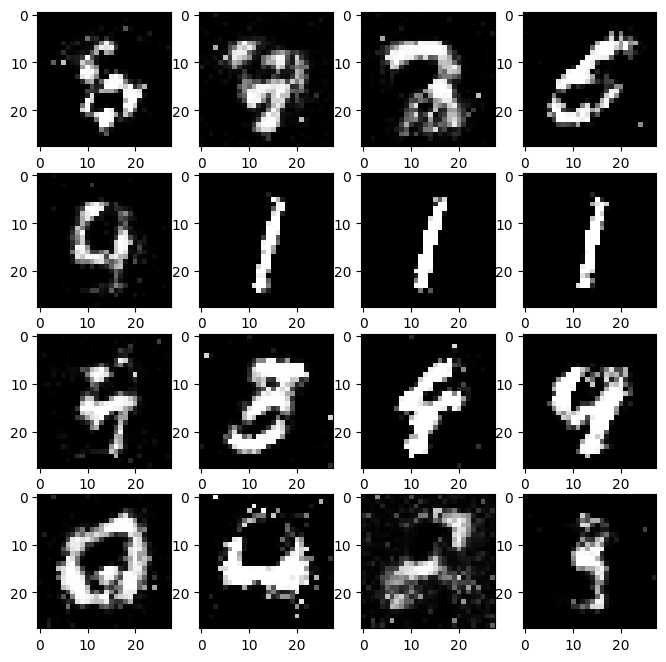

Epoch 39/200 (19.0%): [0/60032] (0.0%) D Error: 1.0228 G Error: 1.7539


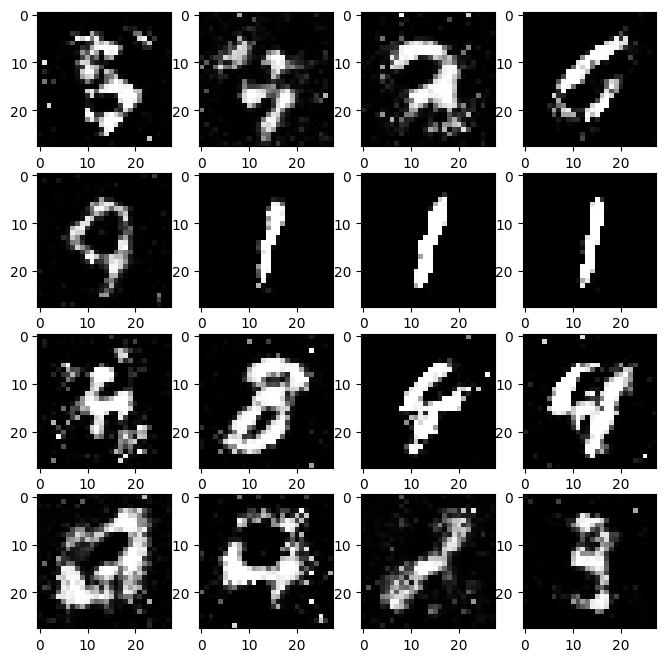

Epoch 40/200 (19.5%): [0/60032] (0.0%) D Error: 1.1157 G Error: 1.2001


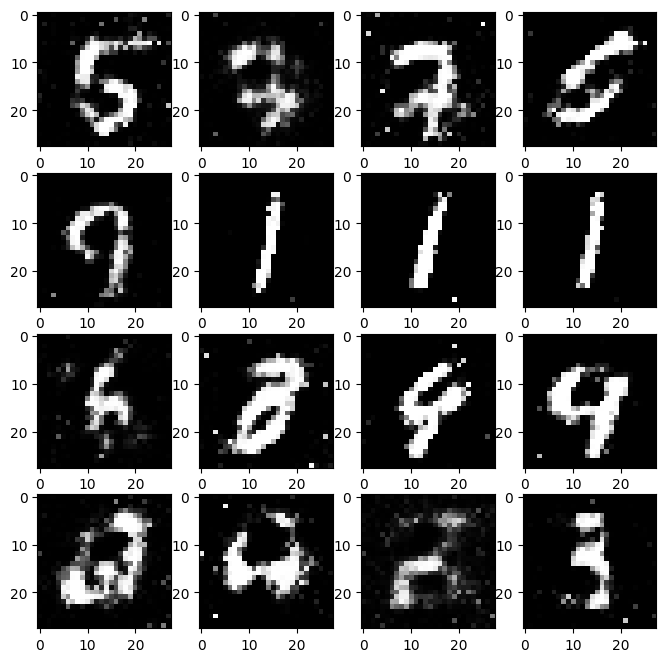

Epoch 41/200 (20.0%): [0/60032] (0.0%) D Error: 0.8311 G Error: 1.4691


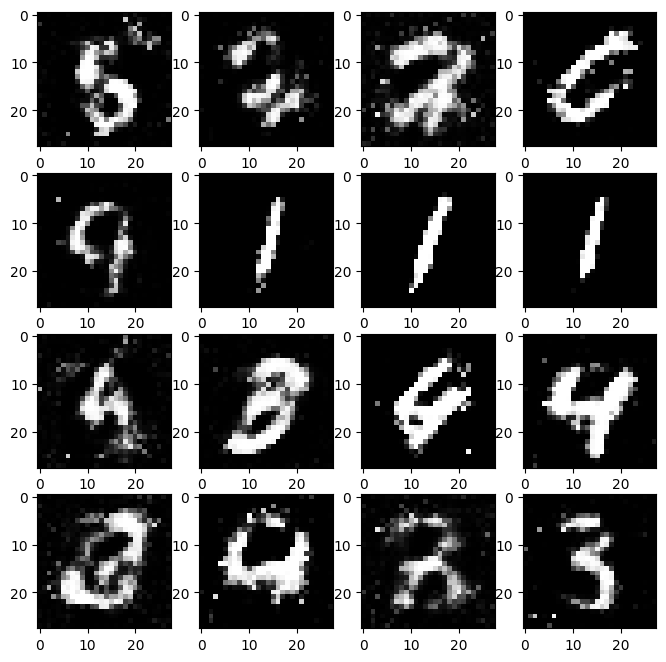

Epoch 42/200 (20.5%): [0/60032] (0.0%) D Error: 1.0983 G Error: 1.5113


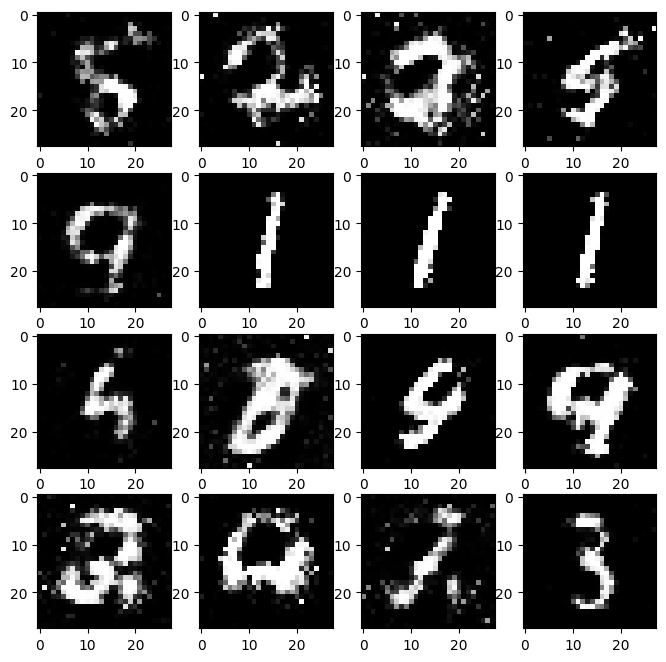

Epoch 43/200 (21.0%): [0/60032] (0.0%) D Error: 1.0724 G Error: 1.1389


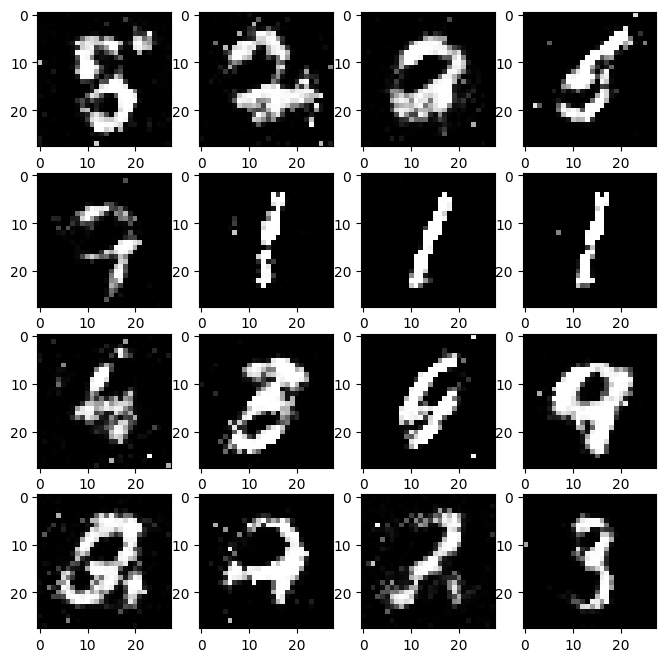

Epoch 44/200 (21.5%): [0/60032] (0.0%) D Error: 0.9178 G Error: 1.3296


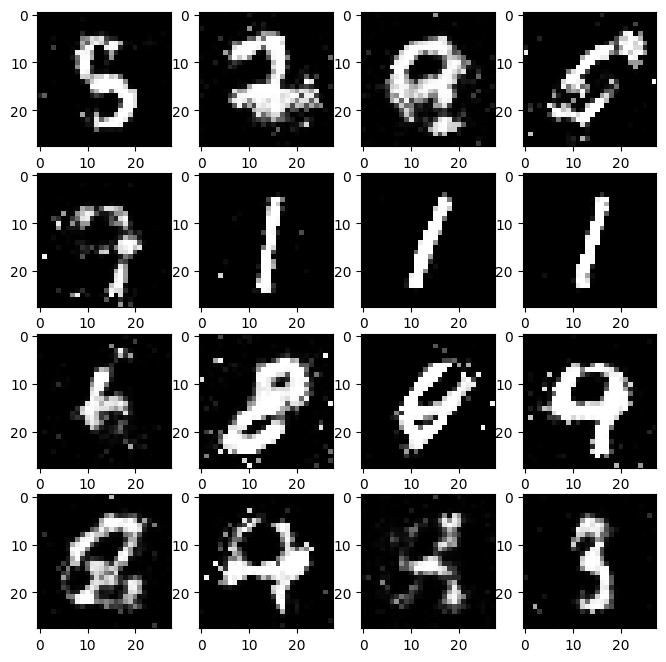

Epoch 45/200 (22.0%): [0/60032] (0.0%) D Error: 0.9937 G Error: 1.3813


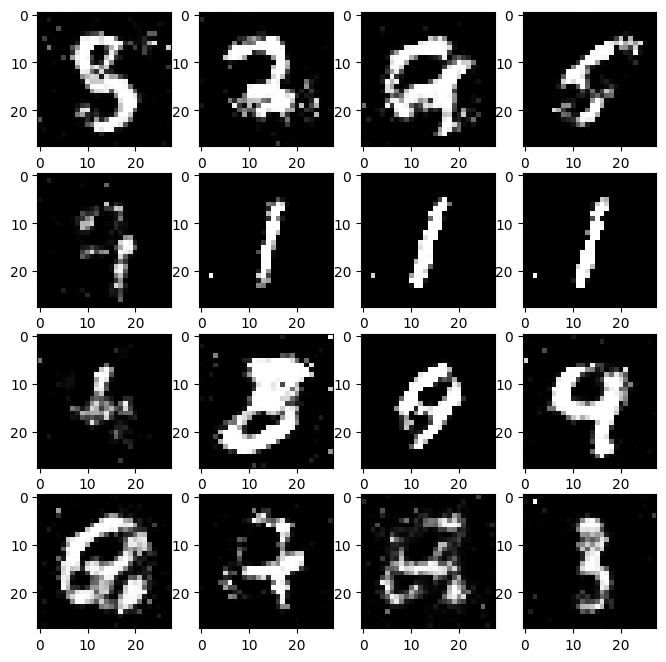

Epoch 46/200 (22.5%): [0/60032] (0.0%) D Error: 1.1657 G Error: 1.2919


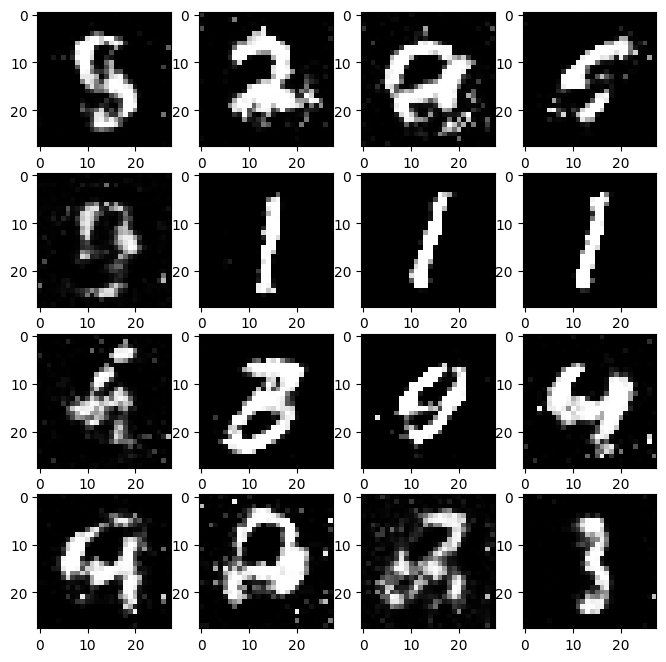

Epoch 47/200 (23.0%): [0/60032] (0.0%) D Error: 1.1440 G Error: 0.9624


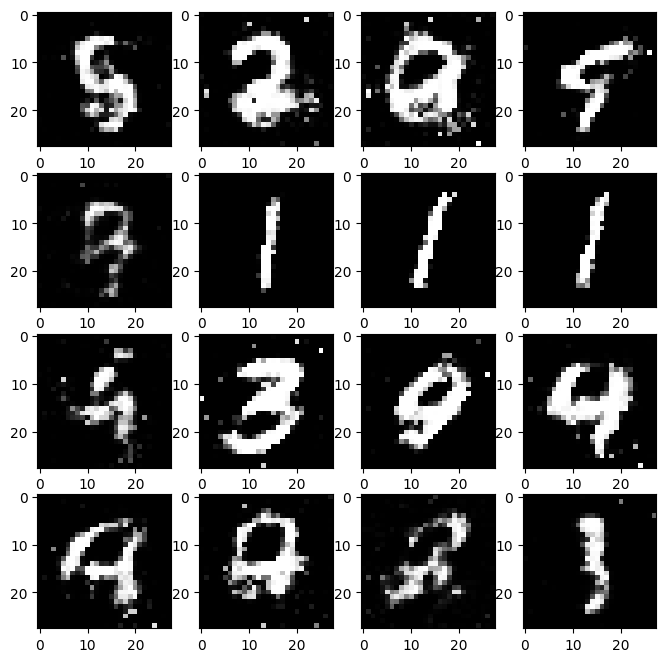

Epoch 48/200 (23.5%): [0/60032] (0.0%) D Error: 1.0446 G Error: 1.2399


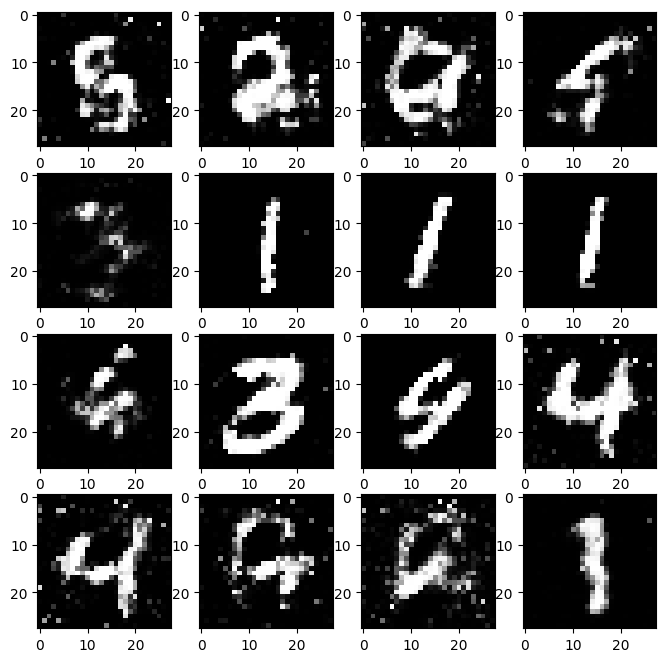

Epoch 49/200 (24.0%): [0/60032] (0.0%) D Error: 0.9697 G Error: 1.1317


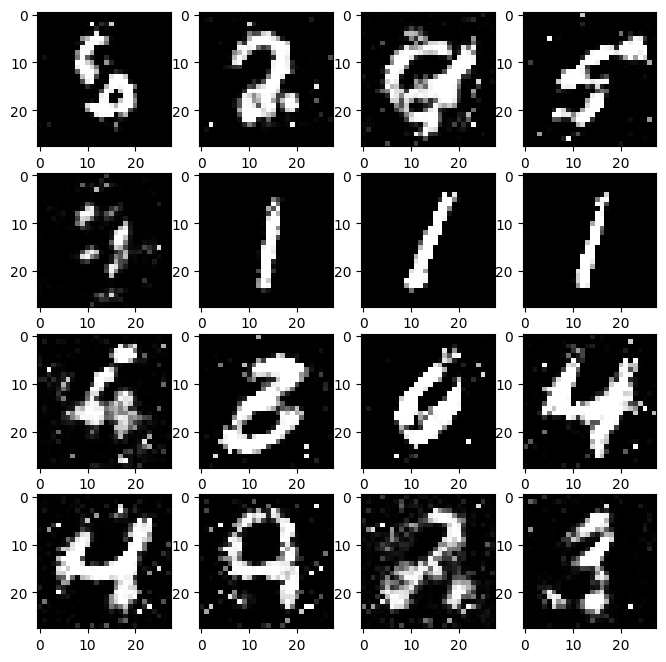

Epoch 50/200 (24.5%): [0/60032] (0.0%) D Error: 1.0349 G Error: 1.2447


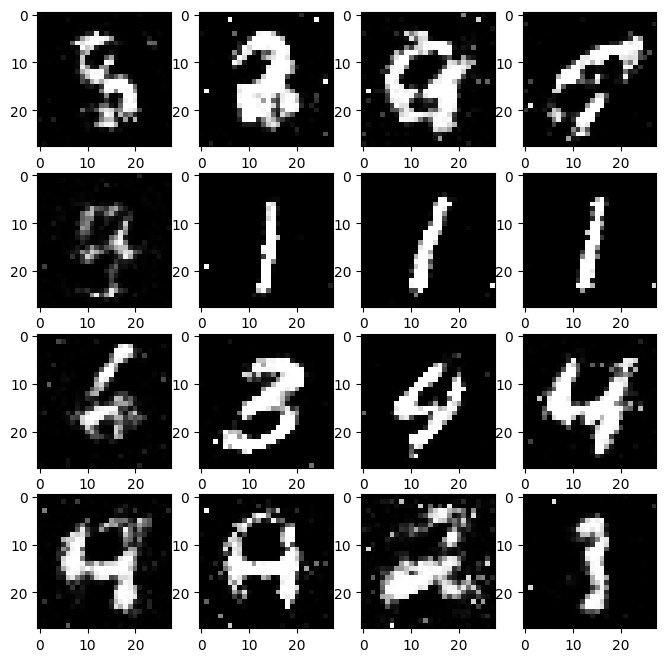

Epoch 51/200 (25.0%): [0/60032] (0.0%) D Error: 0.9165 G Error: 1.3000


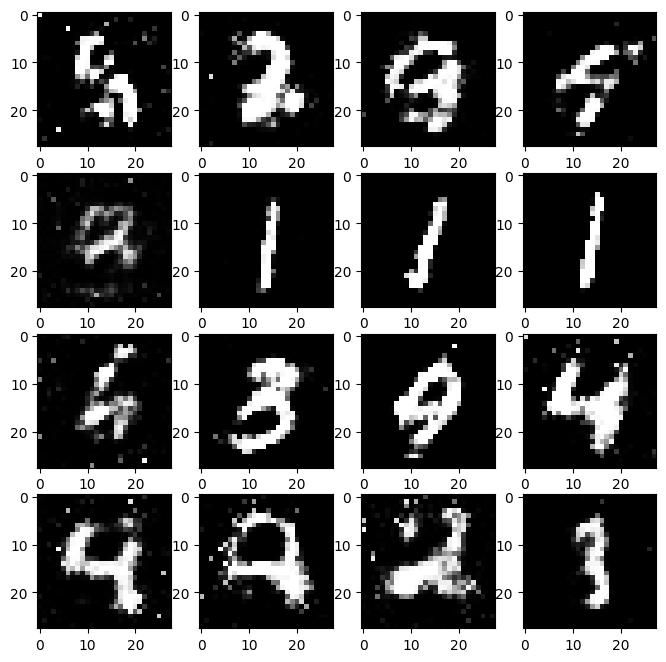

Epoch 52/200 (25.5%): [0/60032] (0.0%) D Error: 1.1681 G Error: 1.1347


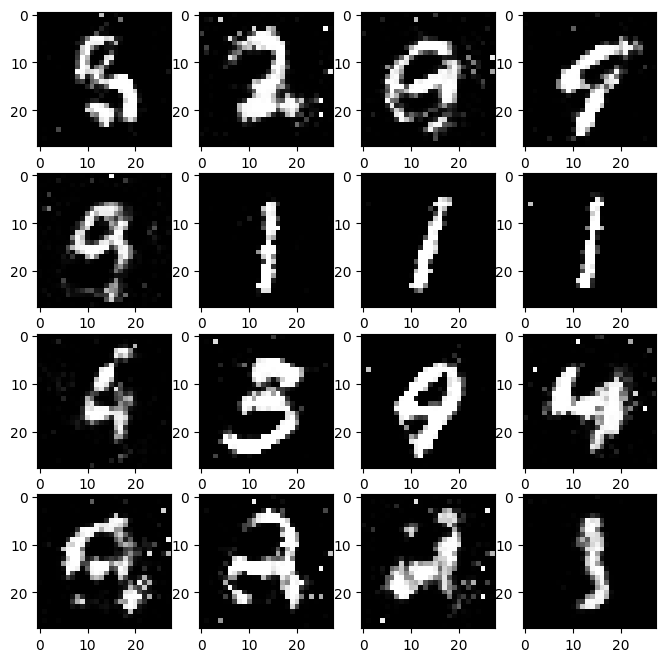

Epoch 53/200 (26.0%): [0/60032] (0.0%) D Error: 1.1172 G Error: 1.2004


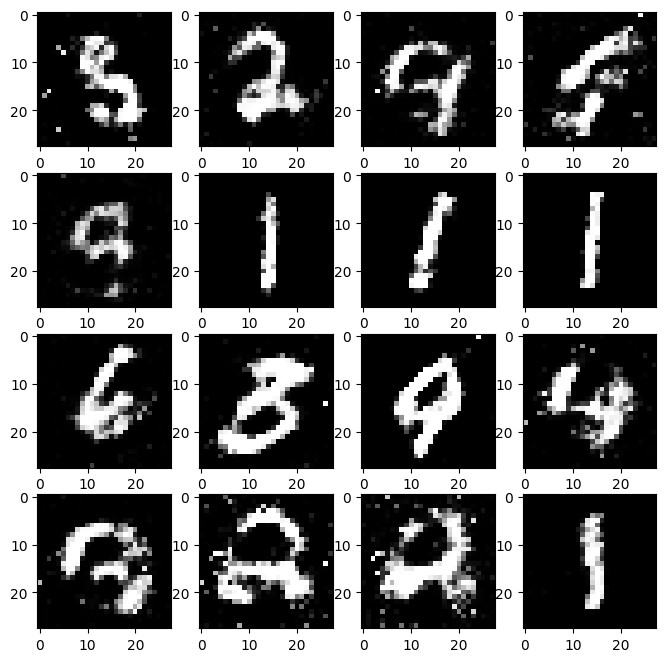

Epoch 54/200 (26.5%): [0/60032] (0.0%) D Error: 1.1338 G Error: 1.2381


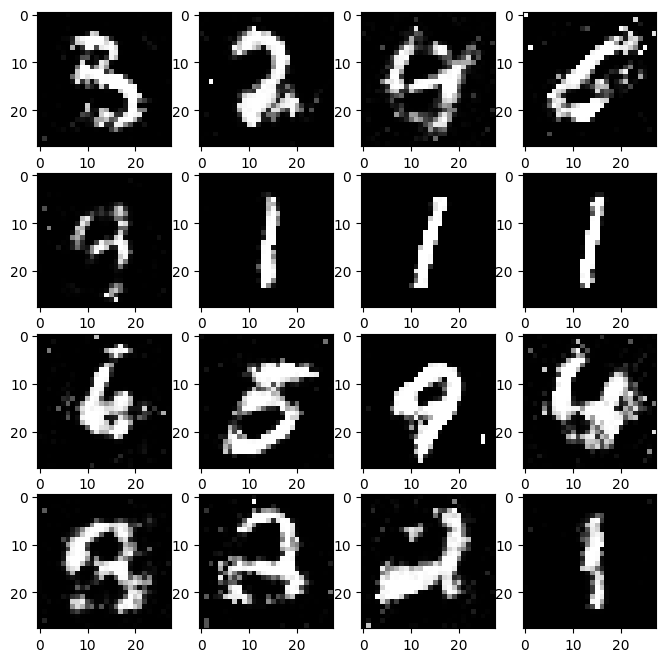

Epoch 55/200 (27.0%): [0/60032] (0.0%) D Error: 0.9117 G Error: 1.5322


In [ ]:
for epoch in range(EPOCHS):
    for batch_idx, (batch, _) in enumerate(data_loader):
        real_data = Variable(imgs_to_vec(batch))
        fake_data = generator(noise(real_data.size(0))).detach()
        d_error, d_pred_real, d_pred_fake, = train_discriminator(
            discriminator, d_optimizer, loss, real_data, fake_data)

        fake_data = generator(noise(real_data.size(0)))
        g_error = train_generator(
            discriminator, g_optimizer, loss, fake_data)


        if (batch_idx % DISPLAY_EVERY) == 0:
            test_images = vec_to_imgs(generator(test_noise)).data.cpu()
            display_images(test_images)
            # Logging
            display_logs(epoch, EPOCHS, batch_idx, NUM_BATCHES,
                         d_error, g_error, d_pred_real, d_pred_fake)